# Test 6.2: K-Sparse Ablation Study

**Гипотеза:** Дисперсия латентного пространства монотонно растёт с увеличением K при нулевых мёртвых нейронах.

**План:**
- K-Sparse Ablation: K ∈ {4, 8, 16, 32, 64, 96, 112}, latent_dim=128, N=3 запуска
- Multiple Runs: N=10 для Dense_ReLU_64, Dense_ReLU_128 и KSparse_Chaos, t-test
- Henon Map Generalization: проверка на второй хаотической системе
- Dead Neuron Tracking: мониторинг нейронов в процессе обучения

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import json
from datetime import datetime
import os

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
def logistic_map(x, r=3.99):
    return r * x * (1 - x)

def generate_logistic_map_image(image_size=28, initial_value=0.4, r=3.99):
    iterations = image_size * image_size
    x = initial_value
    seq = []
    for _ in range(iterations):
        x = logistic_map(x, r)
        seq.append(x)
    img = np.array(seq).reshape((image_size, image_size))
    return img

def generate_logistic_dataset(num_images, image_size=28, r=3.99, fixed_initial=False):
    dataset = []
    for _ in range(num_images):
        init_val = 0.4 if fixed_initial else np.random.rand()
        img = generate_logistic_map_image(image_size=image_size, initial_value=init_val, r=r)
        dataset.append(img)
    return np.array(dataset)[..., np.newaxis].astype('float32')

def henon_map(x, y, a=1.4, b=0.3):
    x = np.clip(x, -2.0, 2.0)
    y = np.clip(y, -2.0, 2.0)
    x_new = 1 - a * x**2 + y
    y_new = b * x
    return x_new, y_new

def generate_henon_image(image_size=28, x0=0.1, y0=0.1, a=1.4, b=0.3):
    iterations = image_size * image_size
    x, y = x0, y0
    points = []
    for _ in range(iterations):
        x, y = henon_map(x, y, a, b)
        normalized = (x + 2.0) / 4.0
        points.append(np.clip(normalized, 0, 1))
    img = np.array(points).reshape((image_size, image_size))
    return img

def generate_henon_dataset(num_images, image_size=28, a=1.4, b=0.3):
    dataset = []
    for _ in range(num_images):
        x0 = np.random.uniform(-0.5, 0.5)
        y0 = np.random.uniform(-0.5, 0.5)
        img = generate_henon_image(image_size, x0, y0, a, b)
        dataset.append(img)
    return np.array(dataset)[..., np.newaxis].astype('float32')

In [3]:
class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super(KSparseLayer, self).__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        latent_dim = tf.shape(inputs)[1]
        values, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype),
            axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


class TargetVarianceRegularizer(layers.Layer):
    def __init__(self, lambda_reg=0.01, target_variance=0.1, **kwargs):
        super(TargetVarianceRegularizer, self).__init__(**kwargs)
        self.lambda_reg = lambda_reg
        self.target_variance = target_variance

    def call(self, inputs):
        current_variance = tf.math.reduce_variance(inputs, axis=0)
        mean_variance = tf.reduce_mean(current_variance)
        variance_penalty = self.lambda_reg * tf.square(
            mean_variance - self.target_variance
        )
        self.add_loss(variance_penalty)
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({
            "lambda_reg": self.lambda_reg,
            "target_variance": self.target_variance
        })
        return config


def chaos_activation(x):
    return tf.sin(8.0 * x) + 0.5 * tf.tanh(4.0 * x)


def build_ksparse_chaos_ae(image_size=(28, 28), latent_dim=128, k_active=32):
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)

    x = layers.Dense(256)(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.2)(x)

    latent_pre = layers.Dense(latent_dim, name='latent_pre')(x)
    latent_pre = layers.Activation(chaos_activation)(latent_pre)

    latent = KSparseLayer(k=k_active, name='latent_ksparse')(latent_pre)
    latent = TargetVarianceRegularizer(
        lambda_reg=0.01,
        target_variance=0.1
    )(latent)

    encoder = keras.Model(input_img, latent, name='ksparse_chaos_encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.1)(x)

    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded, name='ksparse_chaos_autoencoder')
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder, encoder


def build_dense_relu_ae(image_size=(28, 28), latent_dim=64):
    h, w = image_size
    input_img = keras.Input(shape=(h, w, 1))
    x = layers.Flatten()(input_img)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    encoder = keras.Model(input_img, latent, name="dense_encoder")

    x = layers.Dense(128, activation="relu")(latent)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(h * w, activation="sigmoid")(x)
    decoded = layers.Reshape((h, w, 1))(x)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

    return autoencoder, encoder

In [4]:
def analyze_latent_statistics(encoder, images, zero_threshold=1e-6):
    latents = encoder.predict(images, verbose=0)

    variance_per_dim = np.var(latents, axis=0)
    mean_variance = float(np.mean(variance_per_dim))

    dead_mask = np.all(np.abs(latents) < zero_threshold, axis=0)
    dead_neurons = int(np.sum(dead_mask))
    total_neurons = latents.shape[1]

    zero_mask = np.abs(latents) < zero_threshold
    overall_sparsity = np.mean(zero_mask)

    active_per_sample = np.sum(~zero_mask, axis=1)
    mean_active = np.mean(active_per_sample)

    variance_active = []
    for dim in range(latents.shape[1]):
        dim_values = latents[:, dim]
        active_mask = ~zero_mask[:, dim]
        if np.sum(active_mask) > 1:
            active_values = dim_values[active_mask]
            variance_active.append(np.var(active_values))

    mean_variance_active = np.mean(variance_active) if variance_active else 0.0

    return {
        'variance_per_dim': variance_per_dim,
        'mean_variance': mean_variance,
        'dead_neurons': dead_neurons,
        'total_neurons': total_neurons,
        'dead_percentage': dead_neurons / total_neurons,
        'overall_sparsity': overall_sparsity,
        'mean_active_neurons': mean_active,
        'mean_variance_active': mean_variance_active,
        'latents': latents
    }

In [5]:
train_images = generate_logistic_dataset(2000, fixed_initial=False)
test_images = generate_logistic_dataset(500, fixed_initial=False)

k_values = [4, 8, 16, 32, 64, 96, 112]
latent_dim = 128
num_k_runs = 3
k_results = {}

print(f"Testing K values: {k_values}")
print(f"Latent dimension: {latent_dim}")
print(f"Runs per K: {num_k_runs}")

for k in k_values:
    print(f"\n[K={k}]")
    run_stats = []

    for run in range(num_k_runs):
        np.random.seed(run * 100 + k)
        tf.random.set_seed(run * 100 + k)

        ae, enc = build_ksparse_chaos_ae(latent_dim=latent_dim, k_active=k)
        history = ae.fit(
            train_images, train_images,
            epochs=10,
            batch_size=64,
            validation_split=0.1,
            verbose=0
        )

        s = analyze_latent_statistics(enc, test_images)
        run_stats.append({
            'stats': s,
            'val_loss': history.history['val_loss'][-1],
        })
        print(f"  Run {run+1}/{num_k_runs}: var={s['mean_variance']:.6f} "
              f"dead={s['dead_neurons']}/{latent_dim} "
              f"loss={history.history['val_loss'][-1]:.6f}")

    variances = [r['stats']['mean_variance'] for r in run_stats]
    dead_counts = [r['stats']['dead_neurons'] for r in run_stats]
    losses = [r['val_loss'] for r in run_stats]

    k_results[k] = {
        'mean_variance': np.mean(variances),
        'std_variance': np.std(variances),
        'mean_dead': np.mean(dead_counts),
        'mean_val_loss': np.mean(losses),
        'std_val_loss': np.std(losses),
        'sparsity': (latent_dim - k) / latent_dim
    }

Testing K values: [4, 8, 16, 32, 64, 96, 112]
Latent dimension: 128
Runs per K: 3

[K=4]


2026-03-09 13:54:49.970790: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-03-09 13:54:49.970814: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-03-09 13:54:49.970817: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-03-09 13:54:49.970832: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-09 13:54:49.970840: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-03-09 13:54:50.355515: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Run 1/3: var=0.067934 dead=0/128 loss=0.118508
  Run 2/3: var=0.068051 dead=0/128 loss=0.118449
  Run 3/3: var=0.068031 dead=0/128 loss=0.118673

[K=8]
  Run 1/3: var=0.130380 dead=0/128 loss=0.118477
  Run 2/3: var=0.130524 dead=0/128 loss=0.118712
  Run 3/3: var=0.130730 dead=0/128 loss=0.118290

[K=16]
  Run 1/3: var=0.237740 dead=0/128 loss=0.118731
  Run 2/3: var=0.239551 dead=0/128 loss=0.118639
  Run 3/3: var=0.237544 dead=0/128 loss=0.118887

[K=32]
  Run 1/3: var=0.415812 dead=0/128 loss=0.119613
  Run 2/3: var=0.419599 dead=0/128 loss=0.119640
  Run 3/3: var=0.410638 dead=0/128 loss=0.119397

[K=64]
  Run 1/3: var=0.555961 dead=0/128 loss=0.120475
  Run 2/3: var=0.582811 dead=0/128 loss=0.120838
  Run 3/3: var=0.575153 dead=0/128 loss=0.120592

[K=96]
  Run 1/3: var=0.634548 dead=0/128 loss=0.121321
  Run 2/3: var=0.643092 dead=0/128 loss=0.121390
  Run 3/3: var=0.646095 dead=0/128 loss=0.121690

[K=112]
  Run 1/3: var=0.654038 dead=0/128 loss=0.121476
  Run 2/3: var=0.6552

In [6]:
header = f"\n{'K':<5} {'Sparsity':<10} {'Variance':<18} {'Dead':<10} {'Val Loss'}"
print(header)
print("-" * 60)

for k in k_values:
    r = k_results[k]
    print(f"{k:<5} {r['sparsity']:<10.1%} {r['mean_variance']:.4f} +/- {r['std_variance']:.4f}  "
          f"{r['mean_dead']:.0f}/{latent_dim:<6} {r['mean_val_loss']:.4f}")

# Monotonicity check
variances = [k_results[k]['mean_variance'] for k in k_values]
violations = sum(1 for i in range(len(variances)-1) if variances[i+1] < variances[i])
print(f"\nTrend violations: {violations}/{len(variances)-1}")


K     Sparsity   Variance           Dead       Val Loss
------------------------------------------------------------
4     96.9%      0.0680 +/- 0.0001  0/128    0.1185
8     93.8%      0.1305 +/- 0.0001  0/128    0.1185
16    87.5%      0.2383 +/- 0.0009  0/128    0.1188
32    75.0%      0.4153 +/- 0.0037  0/128    0.1195
64    50.0%      0.5713 +/- 0.0113  0/128    0.1206
96    25.0%      0.6412 +/- 0.0049  0/128    0.1215
112   12.5%      0.6537 +/- 0.0013  0/128    0.1215

Trend violations: 0/6


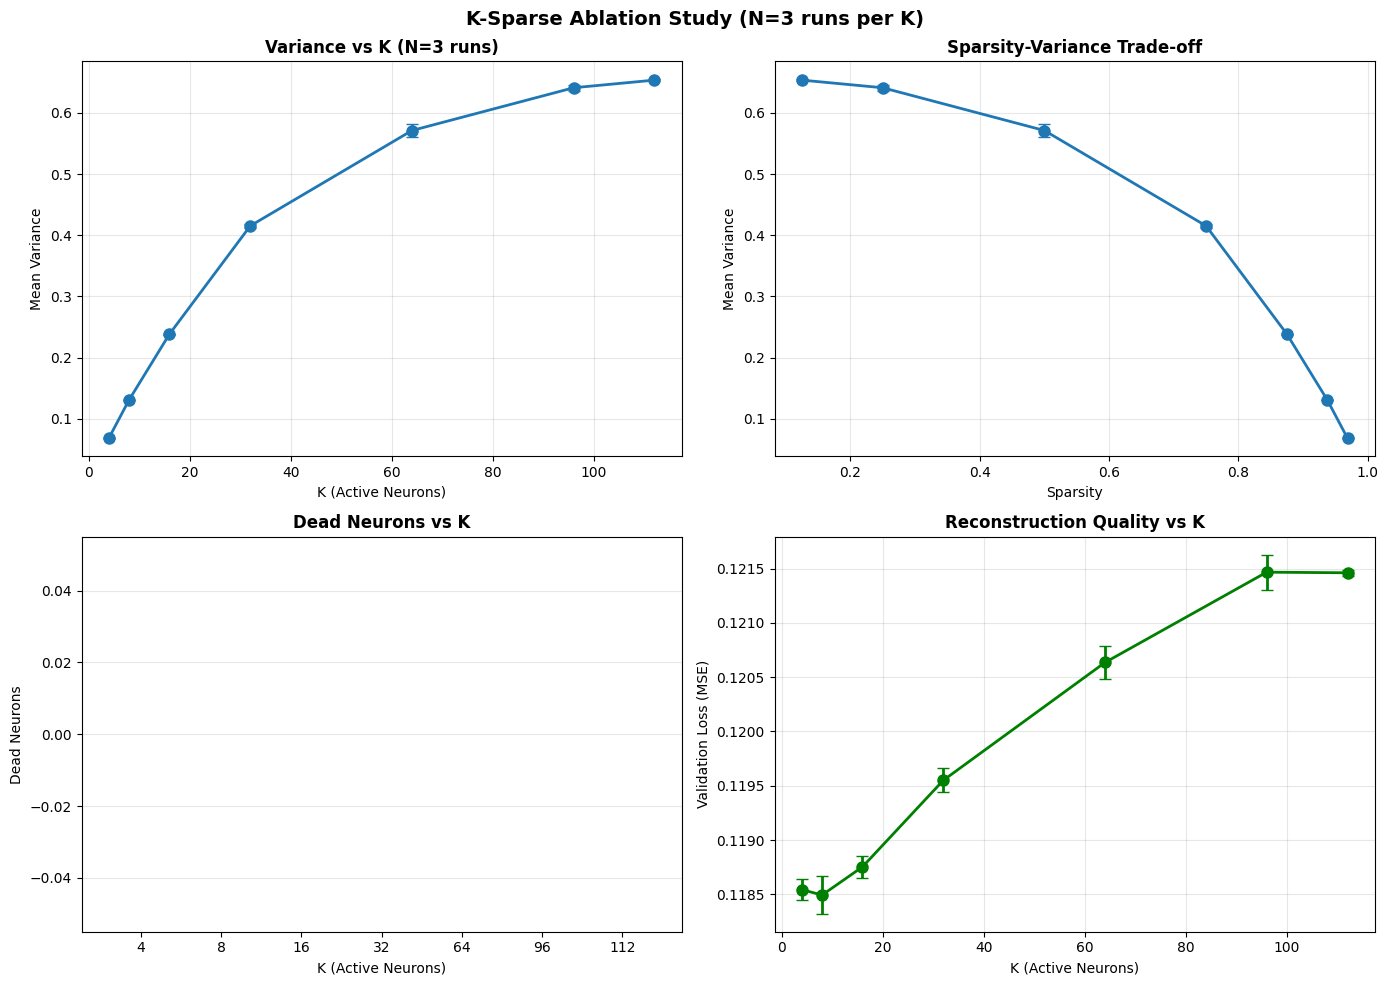

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

k_vals = k_values
variances = [k_results[k]['mean_variance'] for k in k_vals]
var_stds = [k_results[k]['std_variance'] for k in k_vals]
sparsities = [k_results[k]['sparsity'] for k in k_vals]
dead = [k_results[k]['mean_dead'] for k in k_vals]
losses = [k_results[k]['mean_val_loss'] for k in k_vals]
loss_stds = [k_results[k]['std_val_loss'] for k in k_vals]

axes[0, 0].errorbar(k_vals, variances, yerr=var_stds, fmt='o-', linewidth=2, markersize=8, capsize=4)
axes[0, 0].set_xlabel('K (Active Neurons)')
axes[0, 0].set_ylabel('Mean Variance')
axes[0, 0].set_title(f'Variance vs K (N={num_k_runs} runs)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].errorbar(sparsities, variances, yerr=var_stds, fmt='o-', linewidth=2, markersize=8, capsize=4)
axes[0, 1].set_xlabel('Sparsity')
axes[0, 1].set_ylabel('Mean Variance')
axes[0, 1].set_title('Sparsity-Variance Trade-off', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].bar(range(len(k_vals)), dead, color='steelblue', alpha=0.7)
axes[1, 0].set_xticks(range(len(k_vals)))
axes[1, 0].set_xticklabels(k_vals)
axes[1, 0].set_xlabel('K (Active Neurons)')
axes[1, 0].set_ylabel('Dead Neurons')
axes[1, 0].set_title('Dead Neurons vs K', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].errorbar(k_vals, losses, yerr=loss_stds, fmt='o-', linewidth=2, markersize=8, capsize=4, color='green')
axes[1, 1].set_xlabel('K (Active Neurons)')
axes[1, 1].set_ylabel('Validation Loss (MSE)')
axes[1, 1].set_title('Reconstruction Quality vs K', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'K-Sparse Ablation Study (N={num_k_runs} runs per K)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('k_sparse_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
num_runs = 10
architectures = {
    'Dense_ReLU_64': lambda: build_dense_relu_ae(latent_dim=64),
    'Dense_ReLU_128': lambda: build_dense_relu_ae(latent_dim=128),
    'KSparse_Chaos': lambda: build_ksparse_chaos_ae(latent_dim=128, k_active=32)
}

multi_results = {name: [] for name in architectures.keys()}

for arch_name, builder in architectures.items():
    print(f"\n{arch_name}:")
    for run in range(num_runs):
        np.random.seed(run)
        tf.random.set_seed(run)

        ae, enc = builder()
        history = ae.fit(
            train_images, train_images,
            epochs=10,
            batch_size=64,
            validation_split=0.1,
            verbose=0
        )

        s = analyze_latent_statistics(enc, test_images)
        multi_results[arch_name].append({
            'run': run,
            'stats': s,
            'val_loss': history.history['val_loss'][-1]
        })

        print(f"  Run {run+1}/{num_runs}: var={s['mean_variance']:.6f} "
              f"dead={s['dead_neurons']}/{s['total_neurons']} "
              f"loss={history.history['val_loss'][-1]:.6f}")


Dense_ReLU_64:
  Run 1/10: var=0.367387 dead=0/64 loss=0.120287
  Run 2/10: var=0.320821 dead=0/64 loss=0.117935
  Run 3/10: var=0.328362 dead=0/64 loss=0.119045
  Run 4/10: var=0.360852 dead=0/64 loss=0.118524
  Run 5/10: var=0.343458 dead=0/64 loss=0.119087
  Run 6/10: var=0.324235 dead=0/64 loss=0.118051
  Run 7/10: var=0.349823 dead=0/64 loss=0.118276
  Run 8/10: var=0.331898 dead=0/64 loss=0.119227
  Run 9/10: var=0.325226 dead=0/64 loss=0.119217
  Run 10/10: var=0.312759 dead=0/64 loss=0.117736

Dense_ReLU_128:
  Run 1/10: var=0.252142 dead=0/128 loss=0.119678
  Run 2/10: var=0.249667 dead=0/128 loss=0.118208
  Run 3/10: var=0.251252 dead=0/128 loss=0.119625
  Run 4/10: var=0.245468 dead=0/128 loss=0.119262
  Run 5/10: var=0.254722 dead=0/128 loss=0.121719
  Run 6/10: var=0.258980 dead=0/128 loss=0.118514
  Run 7/10: var=0.239362 dead=0/128 loss=0.119948
  Run 8/10: var=0.251481 dead=0/128 loss=0.119180
  Run 9/10: var=0.234704 dead=0/128 loss=0.117228
  Run 10/10: var=0.253115 

In [9]:
for arch_name, runs in multi_results.items():
    print(f"\n{arch_name}:")
    variances = [r['stats']['mean_variance'] for r in runs]
    dead_counts = [r['stats']['dead_neurons'] for r in runs]
    losses = [r['val_loss'] for r in runs]

    print(f"  Variance: {np.mean(variances):.6f} +/- {np.std(variances):.6f}")
    print(f"  Dead neurons: {np.mean(dead_counts):.1f} +/- {np.std(dead_counts):.1f}")
    print(f"  Val loss: {np.mean(losses):.6f} +/- {np.std(losses):.6f}")

# Pairwise t-tests
arch_names = list(multi_results.keys())
print(f"\nPairwise Welch t-tests (variance):")
for i in range(len(arch_names)):
    for j in range(i+1, len(arch_names)):
        vars_i = [r['stats']['mean_variance'] for r in multi_results[arch_names[i]]]
        vars_j = [r['stats']['mean_variance'] for r in multi_results[arch_names[j]]]
        t_stat, p_value = stats.ttest_ind(vars_i, vars_j, equal_var=False)
        print(f"  {arch_names[i]} vs {arch_names[j]}: t={t_stat:.4f}, p={p_value:.6f}")


Dense_ReLU_64:
  Variance: 0.336482 +/- 0.017168
  Dead neurons: 0.0 +/- 0.0
  Val loss: 0.118739 +/- 0.000739

Dense_ReLU_128:
  Variance: 0.249089 +/- 0.006932
  Dead neurons: 0.0 +/- 0.0
  Val loss: 0.119191 +/- 0.001144

KSparse_Chaos:
  Variance: 0.417916 +/- 0.003238
  Dead neurons: 0.0 +/- 0.0
  Val loss: 0.119483 +/- 0.000038

Pairwise Welch t-tests (variance):
  Dense_ReLU_64 vs Dense_ReLU_128: t=14.1608, p=0.000000
  Dense_ReLU_64 vs KSparse_Chaos: t=-13.9837, p=0.000000
  Dense_ReLU_128 vs KSparse_Chaos: t=-66.2025, p=0.000000


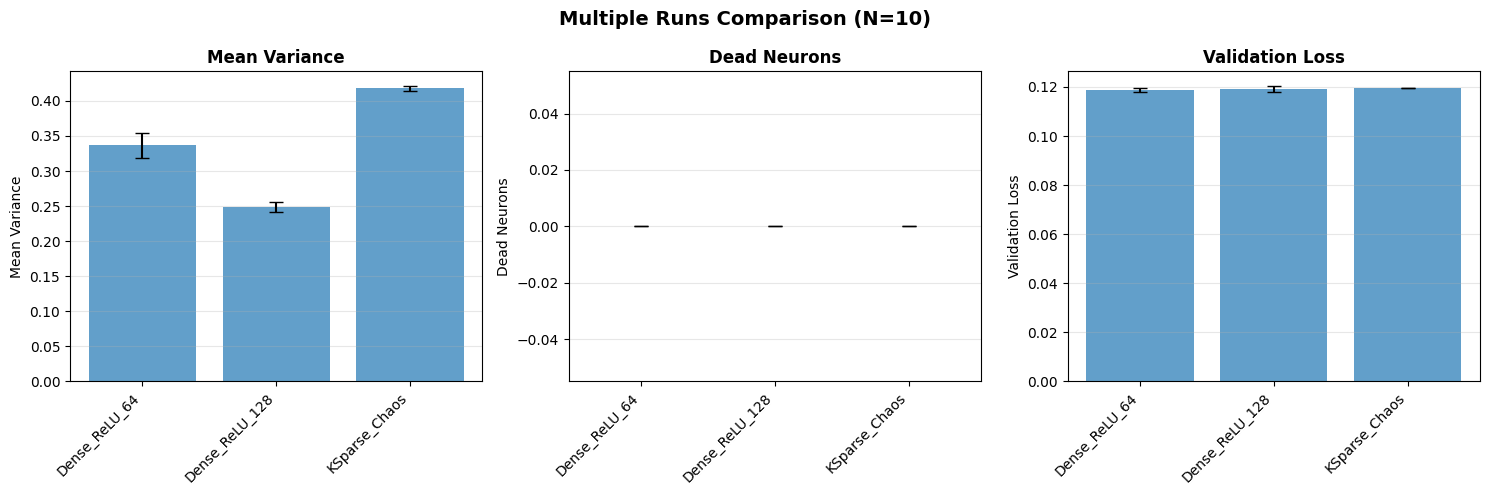

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

arch_names = list(multi_results.keys())
x = np.arange(len(arch_names))

for idx, metric in enumerate([('mean_variance', 'Mean Variance'),
                               ('dead_neurons', 'Dead Neurons'),
                               ('val_loss', 'Validation Loss')]):
    key, label = metric
    means, stds = [], []
    for arch in arch_names:
        if key == 'val_loss':
            vals = [r['val_loss'] for r in multi_results[arch]]
        else:
            vals = [r['stats'][key] for r in multi_results[arch]]
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    axes[idx].bar(x, means, yerr=stds, capsize=5, alpha=0.7)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(arch_names, rotation=45, ha='right')
    axes[idx].set_ylabel(label)
    axes[idx].set_title(label, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Multiple Runs Comparison (N={num_runs})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('multiple_runs_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
logistic_train = generate_logistic_dataset(2000, fixed_initial=False)
henon_train = generate_henon_dataset(2000)
logistic_test = generate_logistic_dataset(500, fixed_initial=False)
henon_test = generate_henon_dataset(500)

henon_results = {}

for dataset_name, train_data, test_data in [
    ('Logistic', logistic_train, logistic_test),
    ('Henon', henon_train, henon_test)
]:
    print(f"\nTraining on {dataset_name} Map...")
    ae, enc = build_ksparse_chaos_ae(latent_dim=128, k_active=32)
    history = ae.fit(
        train_data, train_data,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )
    s = analyze_latent_statistics(enc, test_data)
    henon_results[dataset_name] = {
        'encoder': enc,
        'stats': s,
        'val_loss': history.history['val_loss'][-1]
    }
    print(f"  Variance: {s['mean_variance']:.6f}")
    print(f"  Dead neurons: {s['dead_neurons']}/{s['total_neurons']}")

log_var = henon_results['Logistic']['stats']['mean_variance']
hen_var = henon_results['Henon']['stats']['mean_variance']
print(f"\nVariance ratio (Henon/Logistic): {hen_var/log_var:.2f}x")


Training on Logistic Map...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1382 - val_loss: 0.1339
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1343 - val_loss: 0.1305
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1312 - val_loss: 0.1282
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1289 - val_loss: 0.1264
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1267 - val_loss: 0.1244
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1248 - val_loss: 0.1229
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1234 - val_loss: 0.1218
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1223 - val_loss: 0.1211
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1214 - val_loss: 0.1204
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1207 - val_loss: 0.1200
  Variance: 0.418981
  Dead neurons: 0/128

Training on Henon Map...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step 

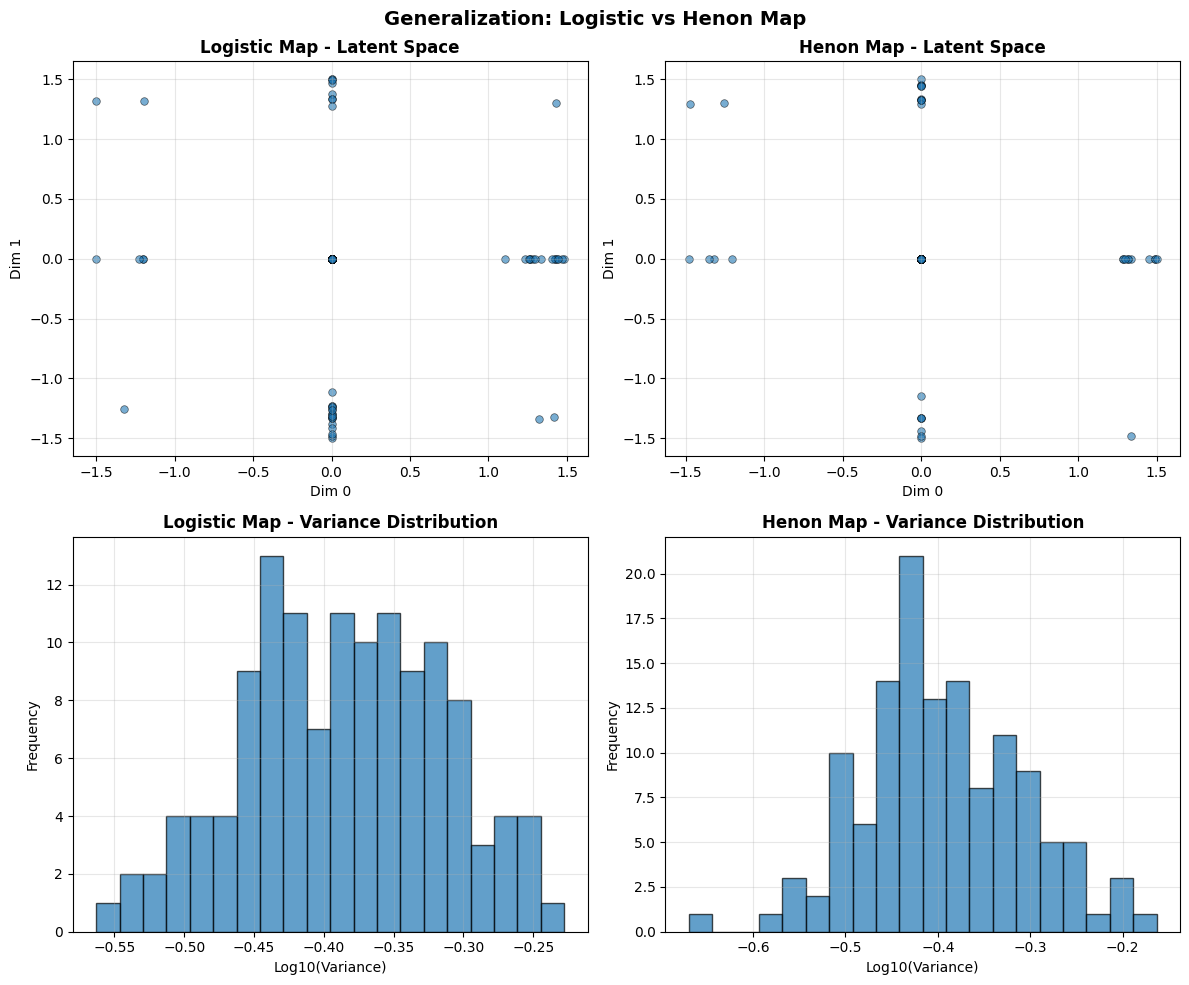

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (name, test_data) in enumerate([
    ('Logistic', logistic_test),
    ('Henon', henon_test)
]):
    enc = henon_results[name]['encoder']
    latents = enc.predict(test_data[:100], verbose=0)

    axes[0, idx].scatter(latents[:, 0], latents[:, 1],
                       alpha=0.6, s=30, edgecolors='black', linewidths=0.5)
    axes[0, idx].set_xlabel('Dim 0')
    axes[0, idx].set_ylabel('Dim 1')
    axes[0, idx].set_title(f'{name} Map - Latent Space', fontweight='bold')
    axes[0, idx].grid(True, alpha=0.3)

    variance = np.var(latents, axis=0)
    axes[1, idx].hist(np.log10(variance + 1e-10), bins=20, alpha=0.7,
                    edgecolor='black')
    axes[1, idx].set_xlabel('Log10(Variance)')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].set_title(f'{name} Map - Variance Distribution', fontweight='bold')
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Generalization: Logistic vs Henon Map', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('henon_generalization.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
def track_dead_neurons_over_time(model, encoder, images, epochs=50, batch_size=64):
    trajectory = []
    for epoch in range(epochs):
        model.fit(images, images, epochs=1, batch_size=batch_size, verbose=0)
        s = analyze_latent_statistics(encoder, images[:200])
        trajectory.append({
            'epoch': epoch,
            'dead_neurons': s['dead_neurons'],
            'mean_variance': s['mean_variance'],
            'sparsity': s['overall_sparsity']
        })
    return trajectory

images = generate_logistic_dataset(1000, fixed_initial=False)

ae, enc = build_ksparse_chaos_ae(latent_dim=128, k_active=32)
trajectory = track_dead_neurons_over_time(ae, enc, images, epochs=30)

print(f"{'Epoch':<8} {'Dead':<8} {'Variance':<12} {'Sparsity'}")
print('-' * 40)
for t in trajectory[::5]:
    print(f"{t['epoch']:<8} {t['dead_neurons']:<8} {t['mean_variance']:<12.6f} {t['sparsity']:.3f}")

Epoch    Dead     Variance     Sparsity
----------------------------------------
0        0        0.422689     0.750
5        0        0.419317     0.750
10       0        0.421029     0.750
15       0        0.422388     0.750
20       0        0.416033     0.750
25       0        0.412518     0.750
